# Principal Component Analysis (PCA) — From Theory to Practice

### Notebook Objective
This notebook builds a complete, practical understanding of **Principal Component Analysis (PCA)** — one of the most widely used dimensionality reduction techniques in machine learning. We implement PCA in two ways: first **from scratch using only NumPy** (so the mathematics is fully transparent), and then using **scikit-learn's production-grade implementation**. By the end, you should be able to explain PCA mathematically, code it yourself, and apply it confidently using a standard library.

### Learning Outcomes
By completing this notebook, you will be able to:
1. Explain what PCA is and why dimensionality reduction matters.
2. Describe the curse of dimensionality and its practical consequences.
3. Compute covariance matrices and perform eigen decomposition by hand (in code).
4. Implement PCA from scratch using NumPy, without relying on any ML library.
5. Use scikit-learn's `PCA` class to reduce dimensionality and interpret `explained_variance_ratio_`.
6. Visualize high-dimensional data in 2D and interpret the resulting plots.
7. Answer common PCA-related interview questions with confidence.

### Prerequisites
- Basic Python and NumPy
- Basic linear algebra: vectors, matrices, dot products
- Familiarity with mean, variance, and covariance (helpful but not mandatory — we recap these below)
- Basic familiarity with pandas DataFrames

### Dataset Description
We use the **Wine recognition dataset**, a classic, small, and clean real-world dataset that comes bundled with scikit-learn (`sklearn.datasets.load_wine`). It contains the results of a chemical analysis of wines grown in the same region of Italy but derived from **three different cultivars (classes)**. There are **178 samples** and **13 numerical features** such as alcohol content, malic acid, ash, flavanoids, color intensity, and proline.

This is a real, measured, laboratory dataset — **no synthetic or randomly generated data is used anywhere in this notebook.**

The same dataset is also publicly available on:
- **UCI Machine Learning Repository**: https://archive.ics.uci.edu/dataset/109/wine
- **Kaggle**: https://www.kaggle.com/datasets/uciml/wine-dataset-for-clustering (and several other Kaggle mirrors of the UCI Wine dataset)

### Credits
- Dataset originally created by Forina, M. et al. and donated to the UCI Machine Learning Repository.
- Distributed with scikit-learn under `sklearn.datasets.load_wine`.
- Notebook authored as part of an applied Machine Learning curriculum, designed to be runnable end-to-end via **Kernel → Restart & Run All**.


### Setting Up: Importing the Libraries We'll Use

**Why we are doing this:** Every tool used in this notebook — array math, tabular data handling, plotting, the dataset itself, and PCA — comes from a small set of standard Python libraries. Importing everything up front means the rest of the notebook can focus purely on PCA rather than library bookkeeping.

**What the code below does:** It imports NumPy and pandas for numerical and tabular data handling, matplotlib and seaborn for plotting, `load_wine` for the dataset, `StandardScaler` for preprocessing, and scikit-learn's `PCA` class for Part 3. It also sets a consistent plot style.

**What you should expect to see:** A single confirmation line, `All libraries imported successfully.`, with no errors. If an import fails, it almost always means a package is missing from the current Python environment.

In [1]:
# --- Core numerical computing library: arrays, linear algebra (eigen decomposition, etc.) ---
import numpy as np

# --- Data handling: lets us store the dataset as a labeled, tabular DataFrame ---
import pandas as pd

# --- Plotting libraries: matplotlib for base plots, seaborn for statistical visualizations ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- The real-world dataset we will use throughout this notebook (no synthetic data) ---
from sklearn.datasets import load_wine

# --- Standardization: PCA is scale-sensitive, so we must standardize features first ---
from sklearn.preprocessing import StandardScaler

# --- Scikit-learn's production-grade PCA implementation (used in Part 3) ---
from sklearn.decomposition import PCA

# --- Used in the cross-validation section to chain scaling + PCA + a classifier together ---
from sklearn.pipeline import Pipeline

# --- Used in the cross-validation section to evaluate downstream classification performance ---
from sklearn.model_selection import cross_val_score

# --- A simple, fast classifier used only to evaluate how useful different n_components values are ---
from sklearn.linear_model import LogisticRegression

# --- Make seaborn plots look clean and professional by default ---
sns.set_style("whitegrid")

print("All libraries imported successfully.")


All libraries imported successfully.


## Theory Recap: What Is PCA, Really?

### What is PCA?
**Principal Component Analysis (PCA)** is an unsupervised technique that takes a dataset with many correlated features and re-expresses it using a smaller number of **new, uncorrelated features** called *principal components*. These new features are ordered so that the first one captures the most variance (information) in the data, the second captures the next most, and so on.

**Analogy:** Imagine photographing a 3D object with a single camera. The 2D photo is a *projection* of the 3D object onto a flat plane. If you choose the camera angle well, the photo still lets you recognize the object clearly — you've lost a dimension but kept most of the useful information. PCA finds the mathematically "best" angle to flatten high-dimensional data while losing as little information as possible.

### The Curse of Dimensionality
As the number of features grows, the data becomes increasingly sparse in that high-dimensional space, distances between points become less meaningful, models need exponentially more data to generalize well, and computation becomes slower. This is called the **curse of dimensionality**. PCA helps by compressing many correlated features into fewer, information-rich ones.

### Variance
Variance measures how spread out a set of values is around its mean. In PCA, **variance is treated as a proxy for "information."** A feature (or direction) along which the data varies a lot is assumed to carry more useful signal than a direction along which the data barely changes.

### Covariance and the Covariance Matrix
Covariance measures how two features change *together*. If two features tend to increase together, their covariance is positive; if one increases as the other decreases, it's negative. For a dataset with several features, we compute a **covariance matrix**, a square matrix where the diagonal holds each feature's variance, and the off-diagonal entries hold pairwise covariances between features.

### Eigenvectors and Eigenvalues
Given the covariance matrix, we find its **eigenvectors** and **eigenvalues**. Each eigenvector points in a direction in feature space along which the data has a certain spread, and the corresponding eigenvalue tells us *how much* variance the data has along that direction. The eigenvector with the largest eigenvalue is the **first principal component** — the direction of maximum variance.

**Analogy:** Think of the data cloud as a rugby ball-shaped cluster of points in space. The eigenvectors point along the long axis, the short axis, and so on, of that rugby ball. The long axis (largest eigenvalue) is the first principal component because it captures the most spread.

### Principal Components and Projection
**Principal components** are the new axes defined by the eigenvectors, sorted by decreasing eigenvalue. **Projection** is the act of re-expressing each data point's coordinates along these new axes (via a dot product), which is how we actually transform the original high-dimensional data into a lower-dimensional representation.

### Applications
PCA is widely used for visualizing high-dimensional data in 2D/3D, removing multicollinearity before regression, speeding up downstream ML models, noise reduction, image compression, and as a preprocessing step before clustering.

> **INTERVIEW NOTE:** Interviewers love asking "Why does PCA maximize variance instead of minimizing some other quantity?" The intuitive answer: directions of high variance are directions where data points are most spread out and therefore most distinguishable from one another — squashing those directions away would destroy the most information.
### When Should You Use PCA?

| Use PCA When | Avoid PCA When |
|--------------|---------------|
| Dataset has many correlated features | Features are already few and manageable |
| You need dimensionality reduction | Interpretability of original features is critical |
| Faster model training is important | Nonlinear structure dominates the data |
| You want visualization in 2D or 3D | Maximum predictive performance is the only goal |
| Memory usage must be reduced | Every original feature must be preserved |

### Practical Rule of Thumb

PCA is most useful when datasets contain many numeric features that are correlated with each other. It is commonly used before clustering, visualization, anomaly detection, and traditional machine-learning pipelines. If preserving feature meaning is more important than compression, PCA may not be the best choice.


## Step 1: Loading and Exploring the Wine Dataset

We now load the real-world Wine dataset directly from scikit-learn (`load_wine`), convert it into a pandas DataFrame for easy inspection, and look at its structure using `head()`, `info()`, and `describe()`.

**What to expect:**
- `head()` will show the first 5 rows with all 13 chemical-property features plus a target class.
- `info()` will confirm there are 178 rows, 13 numeric feature columns, and no missing values (all `non-null`).
- `describe()` will show summary statistics (mean, std, min, max, quartiles) for every feature — notice how different the *scales* of features like `magnesium` (~100s) and `nonflavanoid_phenols` (~0.1s) are. This scale mismatch is exactly why we will standardize the data in Step 2.


In [2]:
# --- Load the real-world Wine dataset bundled with scikit-learn ---
wine = load_wine()

# --- Convert the feature matrix into a pandas DataFrame with proper column names ---
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)

# --- Add the target class (0, 1, or 2 -> one of three wine cultivars) as a separate column ---
df["target"] = wine.target

# --- Map numeric target codes to their human-readable class names for clarity ---
df["target_name"] = df["target"].map(dict(enumerate(wine.target_names)))

print("Shape of dataset (rows, columns):", df.shape)
print("\nNumber of samples :", df.shape[0])
print("Number of features:", len(wine.feature_names))
print("Number of classes :", len(wine.target_names))
print("Class names       :", list(wine.target_names))
print("Feature names      :", list(wine.feature_names))

print("\n--- First 5 rows (head) ---")
display(df.head())

print("\n--- Structural info (info) ---")
df.info()

print("\n--- Summary statistics (describe) ---")
display(df.describe())


Shape of dataset (rows, columns): (178, 15)

Number of samples : 178
Number of features: 13
Number of classes : 3
Class names       : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Feature names      : ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

--- First 5 rows (head) ---


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0



--- Structural info (info) ---
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null 

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


## Step 2: Preprocessing — Cleaning and Standardizing the Data

Before applying PCA, we must prepare the data carefully:

1. **Check for missing values** — PCA cannot handle NaNs; we must verify the dataset is clean.
2. **Check for duplicate rows** — Duplicates can artificially inflate variance along certain directions.
3. **Separate features (X) from the target (y)** — PCA is unsupervised, so it must never see the class labels while computing components; we keep `y` aside only for later visualization.
4. **Standardize features using `StandardScaler`** — This is the most important step. PCA finds directions of maximum *variance*, so if one feature (e.g., `magnesium`, in the 70–160 range) has a much larger numeric scale than another (e.g., `hue`, in the 0.5–1.7 range), PCA would be dominated by that feature purely due to scale, not because it is actually more informative. Standardization rescales every feature to have **mean 0 and standard deviation 1**, putting all features on equal footing.

**Expected output:** zero missing values, zero duplicate rows, and a standardized feature array where every column has approximately mean 0 and standard deviation 1.


In [3]:
# --- Step 2a: Check for missing values across all columns ---
print("Missing values per column:\n", df.isnull().sum().sum(), "total missing values")

# --- Step 2b: Check for duplicate rows in the dataset ---
print("Number of duplicate rows:", df.duplicated().sum())

# --- Step 2c: Separate features (X) from target labels (y) ---
# We use only the original numeric feature columns (exclude target & target_name)
X = df[wine.feature_names].values   # shape: (178, 13)
y = df["target"].values             # shape: (178,)

print("\nShape of feature matrix X:", X.shape)
print("Shape of target vector y :", y.shape)

# --- Step 2d: Standardize features so each has mean 0 and standard deviation 1 ---
# INTERVIEW NOTE: Always standardize before PCA when features are on different scales/units.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nMean of each standardized feature (should be ~0):")
print(np.round(X_scaled.mean(axis=0), 3))

print("\nStandard deviation of each standardized feature (should be ~1):")
print(np.round(X_scaled.std(axis=0), 3))


Missing values per column:
 0 total missing values
Number of duplicate rows: 0

Shape of feature matrix X: (178, 13)
Shape of target vector y : (178,)

Mean of each standardized feature (should be ~0):
[-0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]

Standard deviation of each standardized feature (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Part 2: Implementing PCA From Scratch (Using Only NumPy)

To truly understand PCA, we now implement it manually, step by step, without using any machine-learning library. This mirrors exactly what `sklearn.decomposition.PCA` does internally.

The manual implementation involves four mathematical steps:

1. **Mean centering** — Subtract the mean of each feature from the data, so the data cloud is centered at the origin. PCA is defined in terms of variance around the mean, so this step is mandatory before computing covariance.
2. **Covariance matrix computation** — Compute the 13×13 covariance matrix of the centered, standardized features, capturing how every pair of features varies together.
3. **Eigen decomposition** — Use `np.linalg.eig()` to compute the eigenvectors and eigenvalues of the covariance matrix. Sort them in descending order of eigenvalue, since larger eigenvalues correspond to directions of greater variance (more "important" principal components).
4. **Projection** — Select the top-`k` eigenvectors (the ones with the largest eigenvalues) and project the centered data onto them via matrix multiplication, producing the lower-dimensional representation.

**In mathematical notation**, if `X` is the standardized data matrix (178 samples × 13 features):
- Mean centering: `Xc = X - mean(X)`
- Covariance matrix: `C = (Xcᵗ · Xc) / (n - 1)`, a 13×13 matrix
- Eigen decomposition: find vector `v` and scalar `λ` such that `C·v = λ·v` (`v` is an eigenvector, `λ` its eigenvalue)
- Projection: `Y = Xc · Vₖ`, where `Vₖ` holds the top-`k` eigenvectors as columns, sorted by largest `λ`

We will implement this as a set of small, well-commented functions, then apply them to the standardized Wine data.

**What you should expect to see:** This cell only defines functions and calls them once at the very end, so running it should print a single confirmation line reporting the shape of the projected data, `(178, 2)`, with no errors.


In [4]:
# ============================================================
# PCA FROM SCRATCH — pure NumPy implementation
# ============================================================

def mean_center(data):
    """
    Step 1: Mean-centering.
    Subtracts the mean of each feature (column) from the data so that
    every feature has a mean of zero. PCA's covariance/variance maths
    is only valid when the data is centered around the origin.
    """
    feature_means = np.mean(data, axis=0)         # mean of every column (feature)
    centered_data = data - feature_means          # broadcast subtraction
    return centered_data, feature_means


def compute_covariance_matrix(centered_data):
    """
    Step 2: Covariance matrix computation.
    Uses the standard formula: Cov = (X^T X) / (n - 1), where X is the
    mean-centered data matrix. The result is a (n_features x n_features)
    symmetric matrix.
    """
    # rowvar=False tells NumPy that columns are features, rows are samples
    covariance_matrix = np.cov(centered_data, rowvar=False)
    return covariance_matrix


def eigen_decompose(covariance_matrix):
    """
    Step 3: Eigen decomposition + sorting.
    np.linalg.eig() returns eigenvalues and eigenvectors of the covariance
    matrix. We sort them in DESCENDING order of eigenvalue, since the
    eigenvector with the largest eigenvalue is the direction of maximum
    variance -> the first principal component.

    INTERVIEW NOTE: For a real, symmetric matrix like a covariance matrix,
    np.linalg.eigh() is more numerically stable and efficient than the general
    np.linalg.eig(). We use eig() here because it is the more commonly known
    general-purpose function, but eigh() is the better choice in production code
    whenever you know the matrix is symmetric (as a covariance matrix always is).
    """
    eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

    # Eigenvalues may come back with a tiny imaginary part due to floating-point
    # error even though the covariance matrix is symmetric -> take the real part.
    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors)

    # Sort indices by eigenvalue in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]   # reorder columns (eigenvectors)

    return sorted_eigenvalues, sorted_eigenvectors


def project_data(centered_data, sorted_eigenvectors, n_components):
    """
    Step 4: Projection.
    Selects the top `n_components` eigenvectors (columns) and projects the
    centered data onto them via matrix multiplication. This produces the
    new, lower-dimensional coordinates of every sample.
    """
    top_eigenvectors = sorted_eigenvectors[:, :n_components]   # (n_features, n_components)
    projected_data = centered_data @ top_eigenvectors          # (n_samples, n_components)
    return projected_data


def pca_from_scratch(data, n_components):
    """
    Full from-scratch PCA pipeline tying together all four steps above.
    Returns the projected data, the sorted eigenvalues, and the sorted
    eigenvectors so we can inspect/interpret every intermediate result.
    """
    centered_data, _ = mean_center(data)  # feature means aren't needed past this point
    covariance_matrix = compute_covariance_matrix(centered_data)
    sorted_eigenvalues, sorted_eigenvectors = eigen_decompose(covariance_matrix)
    projected_data = project_data(centered_data, sorted_eigenvectors, n_components)
    return projected_data, sorted_eigenvalues, sorted_eigenvectors


# --- Apply our from-scratch PCA to the standardized Wine data, reducing to 2 components ---
# (No seed needed here: every step -- centering, covariance, eig() ranking,
# projection -- is fully deterministic given the same input data.)
n_components_scratch = 2
X_pca_scratch, eigvals_scratch, eigvecs_scratch = pca_from_scratch(X_scaled, n_components_scratch)

print("From-scratch PCA complete.")
print("Shape of projected data:", X_pca_scratch.shape)


From-scratch PCA complete.
Shape of projected data: (178, 2)


### Interpreting the From-Scratch PCA Output

**Why we are doing this:** Defining the PCA functions above doesn't tell us whether they actually work — we need to look at the numbers they produce: the eigenvalues, the resulting explained variance, and the new projected coordinates.

**What the code below does:** It prints all 13 sorted eigenvalues, converts them into an explained variance ratio (each eigenvalue divided by the total of all eigenvalues), reports how much variance our chosen 2 components capture, and shows the first 5 rows of the projected 2D data.

**What you should expect to see:** Eigenvalues in strictly decreasing order, an explained variance ratio array that sums to 1.0 across all 13 components, and a combined PC1 + PC2 variance around 55%. These numbers should match scikit-learn's results in Part 3 almost exactly, which is how we'll know our manual implementation is correct.

In [5]:
# --- Display all 13 eigenvalues (one per original feature/dimension), sorted descending ---
print("All eigenvalues (sorted, descending):")
print(np.round(eigvals_scratch, 3))

# --- Explained variance ratio: each eigenvalue's share of the TOTAL variance across all eigenvalues ---
total_variance_scratch = np.sum(eigvals_scratch)
explained_variance_ratio_scratch = eigvals_scratch / total_variance_scratch

print("\nExplained variance ratio (per component, all 13):")
print(np.round(explained_variance_ratio_scratch, 4))

print("\nExplained variance ratio captured by our 2 selected components:")
print("PC1:", round(explained_variance_ratio_scratch[0] * 100, 2), "%")
print("PC2:", round(explained_variance_ratio_scratch[1] * 100, 2), "%")
print("Total (PC1 + PC2):", round(explained_variance_ratio_scratch[:2].sum() * 100, 2), "%")

# --- Show the first 5 rows of the projected (lower-dimensional) coordinates ---
print("\nFirst 5 rows of projected data (new PC1, PC2 coordinates):")
print(np.round(X_pca_scratch[:5], 3))

# INTERVIEW NOTE: Notice that just 2 out of 13 original dimensions already capture
# more than half the dataset's total variance -- this is the core value proposition
# of PCA: massive dimensionality reduction with limited information loss.
print("\nInterpretation: With only", n_components_scratch, "out of 13 original features, we retain",
      round(explained_variance_ratio_scratch[:2].sum() * 100, 2),
      "% of the total variance in the dataset.")


All eigenvalues (sorted, descending):
[4.732 2.511 1.454 0.924 0.858 0.645 0.554 0.35  0.291 0.252 0.227 0.17
 0.104]

Explained variance ratio (per component, all 13):
[0.362  0.1921 0.1112 0.0707 0.0656 0.0494 0.0424 0.0268 0.0222 0.0193
 0.0174 0.013  0.008 ]

Explained variance ratio captured by our 2 selected components:
PC1: 36.2 %
PC2: 19.21 %
Total (PC1 + PC2): 55.41 %

First 5 rows of projected data (new PC1, PC2 coordinates):
[[-3.317  1.443]
 [-2.209 -0.333]
 [-2.517  1.031]
 [-3.757  2.756]
 [-1.009  0.87 ]]

Interpretation: With only 2 out of 13 original features, we retain 55.41 % of the total variance in the dataset.


## Part 3: PCA Using Scikit-learn

Now that we understand PCA's internals, we switch to scikit-learn's `PCA` class — the version you should actually use in real projects.

**Why prefer the library version over our manual implementation?**
- **Numerical stability:** scikit-learn uses optimized, well-tested **Singular Value Decomposition (SVD)**-based solvers rather than raw `eig()`, which is more numerically robust, especially for near-singular or ill-conditioned covariance matrices.
- **Performance:** It is implemented in optimized, compiled code and includes solvers (e.g., `'randomized'`) that scale efficiently to very large or very high-dimensional datasets.
- **Convenience:** Built-in attributes like `explained_variance_ratio_`, `.components_`, `.transform()`, and `.inverse_transform()` save a lot of boilerplate.
- **Integration:** It plugs directly into scikit-learn `Pipeline` objects alongside other preprocessing and modeling steps.

**Key difference from our manual version:** Internally, scikit-learn's default solver computes PCA via SVD of the centered data matrix directly, rather than explicitly forming the covariance matrix and calling `eig()`. The two approaches are mathematically equivalent for this purpose, but SVD avoids some numerical precision issues that can arise when explicitly computing `X^T X`.

**What the code below does:** It creates a `PCA(n_components=2)` object, fits it on the standardized Wine data, and transforms the data to 2D in a single `fit_transform()` call, then prints the explained variance ratio, the component vectors, and the resulting shape.

**What you should expect to see:** Explained variance ratio values that closely match our from-scratch results in Part 2 (tiny differences, if any, come from the different numerical solver used internally).


In [6]:
# --- Instantiate scikit-learn's PCA, reducing to 2 components for direct comparison with Part 2 ---
pca_sklearn = PCA(n_components=2, random_state=42)

# --- Fit PCA on the standardized data AND transform it in one call ---
X_pca_sklearn = pca_sklearn.fit_transform(X_scaled)

print("Original data shape :", X_scaled.shape)
print("Transformed data shape:", X_pca_sklearn.shape)

print("\nExplained variance ratio per component:")
print(np.round(pca_sklearn.explained_variance_ratio_, 4))

print("\nTotal variance explained by 2 components:",
      round(pca_sklearn.explained_variance_ratio_.sum() * 100, 2), "%")

print("\nPrincipal component vectors (rows = components, columns = original features):")
print(np.round(pca_sklearn.components_, 3))

# INTERVIEW NOTE: pca.components_ has shape (n_components, n_features). Each ROW is
# one principal component expressed as a linear combination of the ORIGINAL features.
print("\nShape of components_ matrix:", pca_sklearn.components_.shape)


Original data shape : (178, 13)
Transformed data shape: (178, 2)

Explained variance ratio per component:
[0.362  0.1921]

Total variance explained by 2 components: 55.41 %

Principal component vectors (rows = components, columns = original features):
[[ 0.144 -0.245 -0.002 -0.239  0.142  0.395  0.423 -0.299  0.313 -0.089
   0.297  0.376  0.287]
 [ 0.484  0.225  0.316 -0.011  0.3    0.065 -0.003  0.029  0.039  0.53
  -0.279 -0.164  0.365]]

Shape of components_ matrix: (2, 13)


## Step 3: Visualizing PCA Results

We now create two professional visualizations to make the abstract numbers above concrete:

1. **Explained variance ratio bar chart** — shows how much variance each principal component captures, helping us decide how many components are "worth keeping."
2. **2D PCA scatter plot** — projects all 178 wine samples onto their first two principal components and colors them by their true class label, showing visually how well PCA separates the three wine cultivars even though PCA itself never saw the labels.

**Expected output:** a bar chart with a clearly decreasing trend (PC1 highest, PC2 lower, etc.), and a scatter plot showing three reasonably well-separated colored clusters.


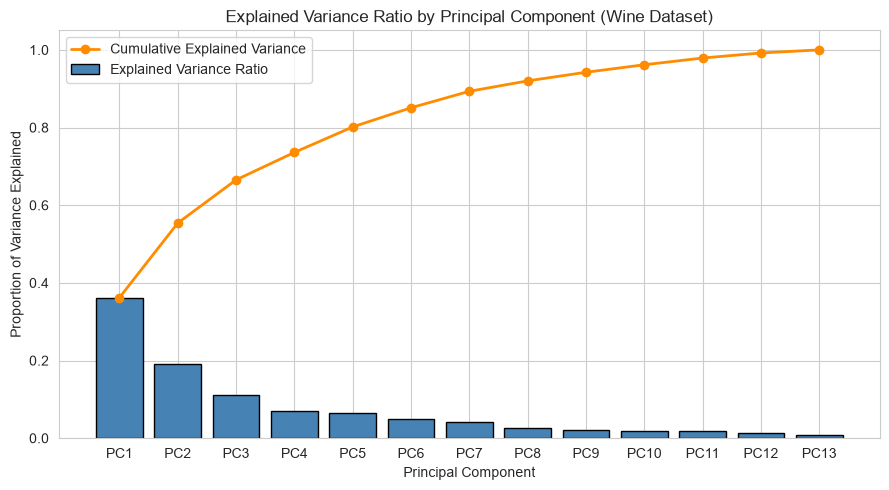

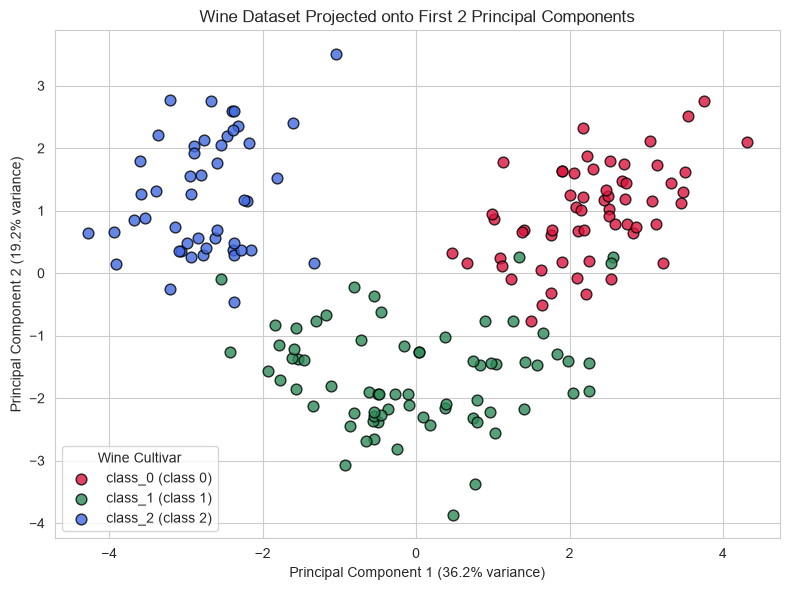

In [7]:
# --- Fit PCA with ALL components first, purely to visualize the FULL explained variance spectrum ---
pca_full = PCA(n_components=None, random_state=42)
pca_full.fit(X_scaled)

# ================= PLOT 1: Explained Variance Ratio Bar Chart =================
plt.figure(figsize=(9, 5))
component_labels = [f"PC{i+1}" for i in range(len(pca_full.explained_variance_ratio_))]
plt.bar(component_labels, pca_full.explained_variance_ratio_,
        color="steelblue", edgecolor="black", label="Explained Variance Ratio")

# Overlay cumulative explained variance as a line for extra interpretability
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(component_labels, cumulative_variance, color="darkorange", marker="o",
          linewidth=2, label="Cumulative Explained Variance")

plt.title("Explained Variance Ratio by Principal Component (Wine Dataset)")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.legend()
plt.tight_layout()
plt.show()

# ================= PLOT 2: 2D PCA Scatter Plot Colored by Class =================
plt.figure(figsize=(8, 6))
class_colors = {0: "crimson", 1: "seagreen", 2: "royalblue"}

for class_index, class_name in enumerate(wine.target_names):
    mask = (y == class_index)
    plt.scatter(
        X_pca_sklearn[mask, 0],
        X_pca_sklearn[mask, 1],
        label=f"{class_name} (class {class_index})",
        color=class_colors[class_index],
        edgecolor="black",
        alpha=0.8,
        s=60,
    )

plt.title("Wine Dataset Projected onto First 2 Principal Components")
plt.xlabel(f"Principal Component 1 ({pca_sklearn.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({pca_sklearn.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Wine Cultivar")
plt.tight_layout()
plt.show()

# INTERVIEW NOTE: Even though PCA is UNSUPERVISED (it never used `y` while
# computing components), the resulting 2D projection still separates the
# three classes reasonably well -- this happens because the chemical
# properties that differ most between cultivars also happen to be the
# directions of highest overall variance in this dataset. This is not
# guaranteed in general; it's a property of this particular dataset.


Why we are doing this:

PCA behavior is controlled by a few important hyperparameters. Understanding them helps us decide how much information to retain, how much dimensionality reduction to perform, and which numerical solver is most appropriate for a given dataset. In real-world projects, selecting the right hyperparameters can significantly affect interpretability, computational cost, and downstream model performance.

## Hyperparameter Discussion: `n_components`, `whiten`, `svd_solver`

### `n_components`
Controls how many principal components to keep.
- An **integer** (e.g., `n_components=2`) keeps exactly that many components — useful for visualization (2D/3D plots).
- A **float between 0 and 1** (e.g., `n_components=0.95`) tells scikit-learn to automatically keep the minimum number of components needed to retain that fraction of total variance — useful in production pipelines where you care about information retention rather than a fixed dimension count.
- **Trade-off:** Fewer components mean faster downstream computation and easier visualization, but more information loss. More components retain more information but reduce the compression benefit.

### `whiten`
When `whiten=True`, the transformed output is additionally rescaled so each principal component has **unit variance** (in addition to being uncorrelated). This is useful before algorithms that assume isotropic (equal-variance) input, such as some clustering or whitening-sensitive neural network preprocessing steps.
- **Trade-off:** Whitening can amplify components with small eigenvalues (which are often dominated by noise), potentially hurting downstream performance if not used carefully.

### `svd_solver`
Controls the numerical algorithm used internally:
- `'full'` — Exact, full SVD computation; most accurate but slower for large datasets.
- `'randomized'` — An approximate, much faster SVD method ideal for large datasets where you only need a small number of components.
- `'arpack'` — Iterative solver, efficient for sparse matrices or when you need fewer components than features.
- `'auto'` (default) — scikit-learn automatically picks the most efficient solver based on input data shape and the requested `n_components`.
- **Trade-off:** Exact solvers (`'full'`) are slower but precise; approximate solvers (`'randomized'`) trade a small amount of accuracy for substantial speed gains on large datasets.

> **INTERVIEW NOTE:** A common follow-up question is "How do you choose the right number of components in practice?" The standard answer: plot the **cumulative explained variance curve** (as we did in Plot 1) and pick the smallest number of components after which the curve "elbows" or crosses a chosen threshold (often 90–95%).


## Step 4: Experimenting With Different `n_components` Values

To make the trade-off concrete, we now fit PCA three separate times on the same standardized Wine data with `n_components = 2`, `3`, and `5`, and compare how much total variance each setting captures.

**Expected output:** a small comparison table showing that as `n_components` increases, the total explained variance also increases (since more directions of spread are retained), approaching 100% as `n_components` approaches the original 13 features.


In [8]:
# --- Try three different values of n_components and record their explained variance ---
component_options = [2, 3, 5]
comparison_records = []

for k in component_options:
    pca_k = PCA(n_components=k, random_state=42)
    pca_k.fit(X_scaled)
    total_explained = pca_k.explained_variance_ratio_.sum()
    comparison_records.append({
        "n_components": k,
        "explained_variance_ratio_per_component": np.round(pca_k.explained_variance_ratio_, 4),
        "total_explained_variance (%)": round(total_explained * 100, 2),
    })

comparison_df = pd.DataFrame(comparison_records)
print("Comparison of different n_components settings:\n")
display(comparison_df)

# INTERVIEW NOTE: Notice the DIMINISHING RETURNS pattern -- going from 2 to 3
# components adds a meaningful chunk of variance, but going from 3 to 5 adds
# progressively smaller increments, since later components capture less and
# less variance by construction (eigenvalues are sorted in descending order).


Comparison of different n_components settings:



,n_components,explained_variance_ratio_per_component,total_explained_variance (%)
0,2,"[0.362, 0.1921]",55.41
1,3,"[0.362, 0.1921, 0.1112]",66.53
2,5,"[0.362, 0.1921, 0.1112, 0.0707, 0.0656]",80.16


## Cross-Validation: Is Higher Explained Variance Always Better?

**Why we are doing this:** The explained-variance numbers we compared above tell us how much of the dataset's total *variance* is kept for a given `n_components` — but they say nothing about whether that retained variance actually helps a real downstream task, such as predicting the wine cultivar. In practice, `n_components` is often chosen using **cross-validation**: we measure how well a downstream model performs for several different values, and pick the one with the best *validated* performance rather than the one with the highest variance retained.

**What the code below does:** It builds a `Pipeline` that scales the data, applies PCA, and trains a `LogisticRegression` classifier — all fit fresh on each training fold so there is no data leakage from the test fold. It repeats this for `n_components` = 2, 3, 5, 8, and 13 using 5-fold cross-validation, and reports the mean classification accuracy for each setting.

**What you should expect to see:** A small table of mean cross-validated accuracy per `n_components`, generally increasing as more components are kept, though the gains should shrink noticeably after the first few components — this is the same diminishing-returns pattern we saw with explained variance, now confirmed on an actual prediction task.

In [9]:
# --- Build a pipeline so StandardScaler + PCA + the classifier are all fit fresh
#     on each cross-validation training fold (avoids leaking test-fold information
#     into preprocessing, unlike if we reused the already-scaled X_scaled directly) ---
component_options_cv = [2, 3, 5, 8, 13]
cv_results = []

for k in component_options_cv:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=k, random_state=42)),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
    ])
    # cv=5 -> 5-fold cross-validation; accuracy is a reasonable metric for this balanced 3-class task
    scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy")
    cv_results.append({
        "n_components": k,
        "mean_cv_accuracy": round(scores.mean(), 4),
        "std_cv_accuracy": round(scores.std(), 4),
    })

cv_results_df = pd.DataFrame(cv_results)
print("Cross-validated downstream classification accuracy for different n_components:\n")
display(cv_results_df)

best_row = cv_results_df.loc[cv_results_df["mean_cv_accuracy"].idxmax()]
print(f"\nBest n_components based on cross-validation: {int(best_row['n_components'])} "
      f"(mean CV accuracy = {best_row['mean_cv_accuracy']})")

# INTERVIEW NOTE: An unsupervised explained-variance curve tells you how much
# INFORMATION is retained, but not whether that information is the part a
# downstream model actually needs. Cross-validation directly measures task
# performance, which is why n_components is often tuned via cross-validation
# (e.g. GridSearchCV) in real pipelines rather than from the variance curve alone.


Cross-validated downstream classification accuracy for different n_components:



,n_components,mean_cv_accuracy,std_cv_accuracy
0,2,0.9551,0.0223
1,3,0.9610,0.0415
2,5,0.9776,0.0208
3,8,0.9778,0.0208
4,13,0.9832,0.0137



Best n_components based on cross-validation: 13 (mean CV accuracy = 0.9832)


## Interview Corner

**Q1. What is PCA?**
PCA is an unsupervised dimensionality reduction technique that transforms a set of possibly correlated features into a smaller set of uncorrelated variables called principal components, ordered by how much variance of the original data they capture.

**Q2. Why standardize before PCA?**
Because PCA finds directions of maximum variance, and variance is scale-dependent. Without standardization, features measured in larger numeric ranges (e.g., magnesium in mg/L) would dominate the principal components purely due to their scale, not their actual information content.

**Q3. Why eigenvectors?**
Eigenvectors of the covariance matrix point in the directions along which the data varies; the corresponding eigenvalues quantify how much variance lies along each direction. The top eigenvectors define the axes that best preserve the data's spread when projecting to fewer dimensions.

**Q4. Why explained variance?**
Explained variance ratio quantifies how much of the original dataset's total information (variance) is retained after reducing dimensions. It guides the decision of how many components to keep, balancing compression against information loss.

**Q5. Difference between PCA and feature selection?**
Feature selection picks a subset of the *original* features as-is (e.g., keeping `alcohol` and `proline`, dropping the rest), so selected features remain interpretable. PCA instead *creates new features* (linear combinations of all original features), which usually capture more information per dimension but are harder to interpret directly.

**Q6. PCA vs t-SNE?**
PCA is a linear technique focused on preserving global variance and works well as a fast preprocessing/compression step. t-SNE is a non-linear technique focused on preserving local neighborhood structure for visualization; it is typically slower, non-deterministic across runs, and not meant for general-purpose dimensionality reduction before modeling (its outputs aren't a stable coordinate system).

**Q7. PCA vs UMAP?**
Like t-SNE, UMAP is non-linear and excels at preserving both local and some global structure for visualization, often faster than t-SNE on large datasets. PCA remains preferable when you need a fast, linear, easily-invertible, and reproducible transformation (e.g., as a preprocessing step in a production ML pipeline), whereas UMAP/t-SNE are typically reserved for exploratory visualization.


## Key Takeaways

- **Dimensionality reduction:** PCA compresses high-dimensional, correlated data (13 Wine features) into a small number of new, uncorrelated principal components, easing visualization and downstream modeling.
- **Variance preservation:** PCA selects directions that maximize retained variance, treating variance as a proxy for "information," so the most important structure in the data is preserved even after compression.
- **Principal components:** These are the eigenvectors of the (standardized) covariance matrix, ranked by eigenvalue, and represent new orthogonal axes that are linear combinations of the original features.
- **Computational efficiency:** Reducing from 13 dimensions to 2–5 principal components significantly speeds up downstream algorithms and reduces storage and noise, with `svd_solver` choices providing further scalability for larger datasets.
- **Practical applications:** PCA is widely used for visualization, noise reduction, multicollinearity removal before regression, and as a preprocessing step in production ML pipelines across domains such as chemistry (as seen with the Wine dataset), finance, genomics, and image processing.
